# NEAT vs HA-NEAT – Reduced Experiment Analysis

**Experiment:** `multi_task_neat_vs_haneat_reduced`  
**Config:** pop=1024, gen=750, compat=0.3, disjoint=1.0, 20 seeds per algorithm  
**Tasks:** Hopper (11 obs / 3 act) + Walker2D (17 obs / 6 act)  
**Fitness:** normalized_min = min(norm_hopper, norm_walker2d)

**Sections:**
1. Setup & genome inventory
2. Training dynamics (MLflow)
3. Genome complexity over generations
4. Activation function usage (HA-NEAT)
5. Re-evaluation
6. Re-evaluation plots
7. Statistical tests + bootstrap CIs
8. Summary

## 1. Setup

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# ── project root on path ────────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd()).parent
for p in [
    str(PROJECT_ROOT),
    str(PROJECT_ROOT / "text" / "figures"),
]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── analysis modules ────────────────────────────────────────────────────────
from analysis.merge import collect_genomes, split_by_algorithm
from analysis.reevaluate import run_reevaluation, build_combined_json, save_json
from analysis.stats import (
    compute_tests, compute_normalized_min, format_txt_report,
    REFERENCE_REWARDS, TASKS as STAT_TASKS,
)
from plot_training_curves import (
    load_metrics, setup_matplotlib,
    ALGO_COLORS, ALGO_DISPLAY,
    _group_by_algorithm, _extract_series, _compute_mean_curve,
)
from plot_evaluation_results import (
    plot_evaluation, ALGO_DOT_COLORS,
)

# ── constants ────────────────────────────────────────────────────────────────
EXPERIMENT         = "multi_task_neat_vs_haneat_reduced"
TASKS              = ["hopper", "walker2d"]
ACTIVATION_OPTIONS = ["tanh", "sigmoid", "relu", "sin", "identity"]
N_EVAL             = 20   # episodes per genome per task
BACKEND            = "mjx"

DB_PATH      = PROJECT_ROOT / "mlflow.db"
RESULTS_ROOT = PROJECT_ROOT / "results"

# Path to the server-generated re-evaluation output
REEVAL_JSON  = (PROJECT_ROOT / "analysis" / "outputs"
                / "multi_task_neat_vs_haneat_reduced_20260424_121849"
                / "reeval" / "combined.json")

# Local figures output dir (keep separate from the server output dir)
FIGURES_DIR  = PROJECT_ROOT / "analysis" / "outputs" / "reduced" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

setup_matplotlib()
print(f"Project root  : {PROJECT_ROOT}")
print(f"Re-eval JSON  : {REEVAL_JSON}  (exists={REEVAL_JSON.exists()})")
print(f"Figures dir   : {FIGURES_DIR}")

Project root  : /Users/svengoerdes/Projects/Thesisv2/tensorneat
Re-eval JSON  : /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/multi_task_neat_vs_haneat_reduced_20260424_121849/reeval/combined.json  (exists=True)
Figures dir   : /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures


## 2. Genome inventory

In [2]:
entries = collect_genomes(str(RESULTS_ROOT), [EXPERIMENT])
groups  = split_by_algorithm(entries)

rows = []
for e in sorted(entries, key=lambda x: (x.algorithm, x.seed or 0)):
    rows.append({
        "algorithm": e.algorithm,
        "seed"     : e.seed,
        "compat"   : e.compat,
        "size_kb"  : round(os.path.getsize(e.path) / 1024, 1),
        "file"     : e.fname,
    })

df_inv = pd.DataFrame(rows)
print(df_inv.groupby("algorithm").size().rename("count"))
display(df_inv)

algorithm
ha_neat    20
neat       20
Name: count, dtype: int64


,algorithm,seed,compat,size_kb,file
0,ha_neat,871,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
1,ha_neat,1227,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
2,ha_neat,1312,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
3,ha_neat,1597,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
4,ha_neat,2164,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
5,ha_neat,2444,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
6,ha_neat,3081,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
7,ha_neat,3715,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
8,ha_neat,4157,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...
9,ha_neat,4335,0.3,4.6,ha_neat_normalized_min_pop1024_gen750_disjoint...


## 3. Training dynamics (MLflow)

In [3]:
METRIC_KEYS = [
    "best_fitness_normalized/hopper",
    "best_fitness_normalized/walker2d",
    "fitness/max",
    "neat/n_species",
    "neat/best_genome_n_nodes",
    "neat/best_genome_n_conns",
]

mlflow_data = load_metrics(str(DB_PATH), EXPERIMENT, METRIC_KEYS)
algo_groups = _group_by_algorithm(mlflow_data)

print(f"Loaded {len(mlflow_data)} runs:")
for algo, runs in sorted(algo_groups.items()):
    print(f"  {ALGO_DISPLAY.get(algo, algo):20s}  {len(runs)} run(s)")

Loaded 40 runs:
  HA-NEAT               20 run(s)
  NEAT                  20 run(s)


  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/training_hopper.pdf


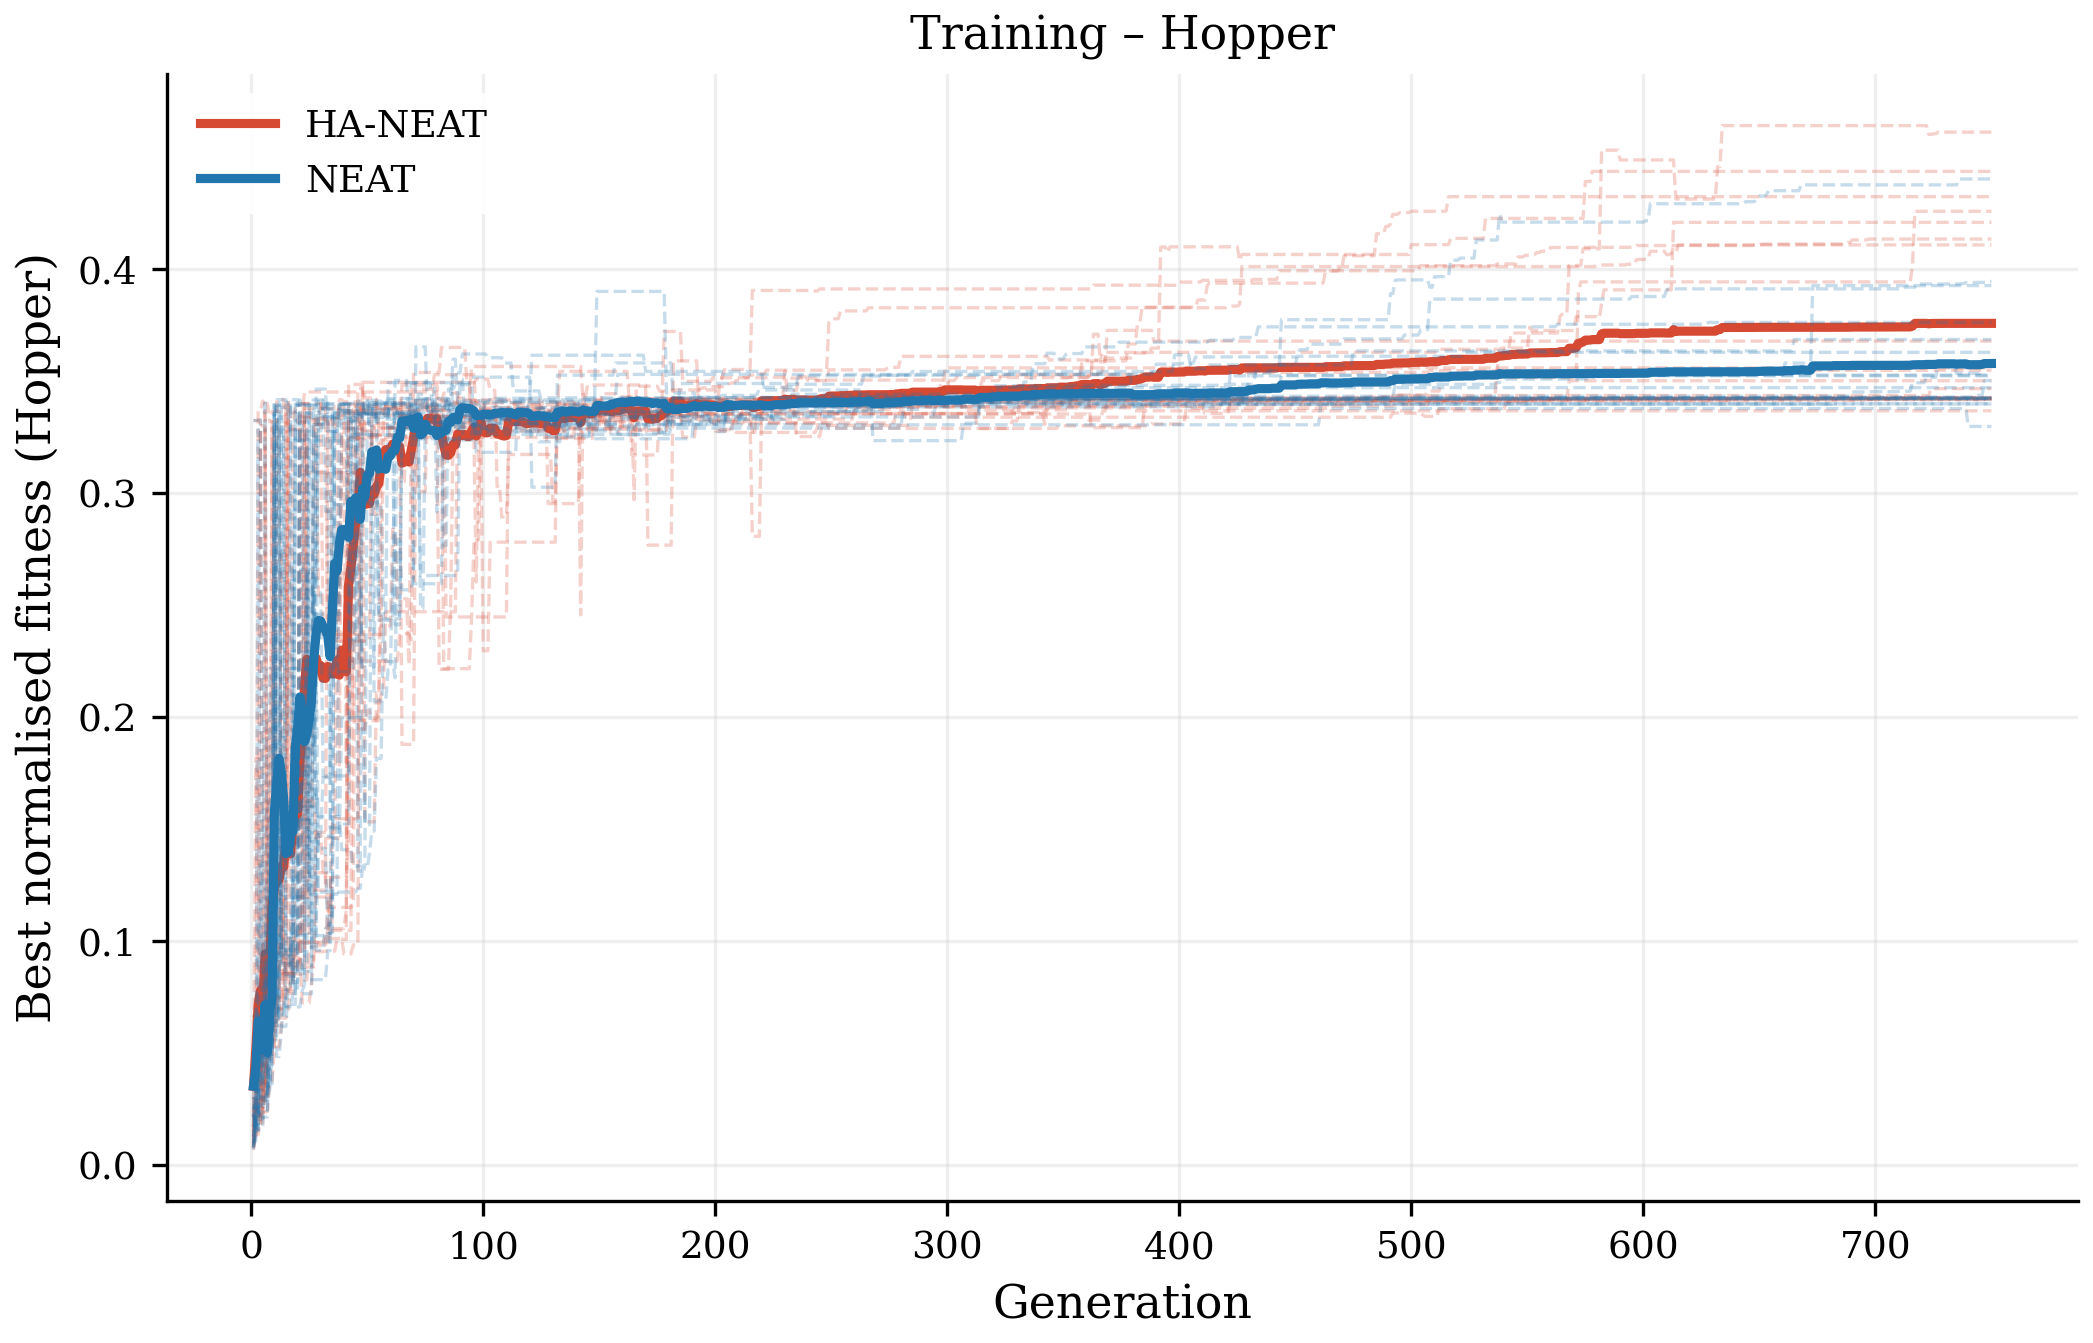

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/training_walker2d.pdf


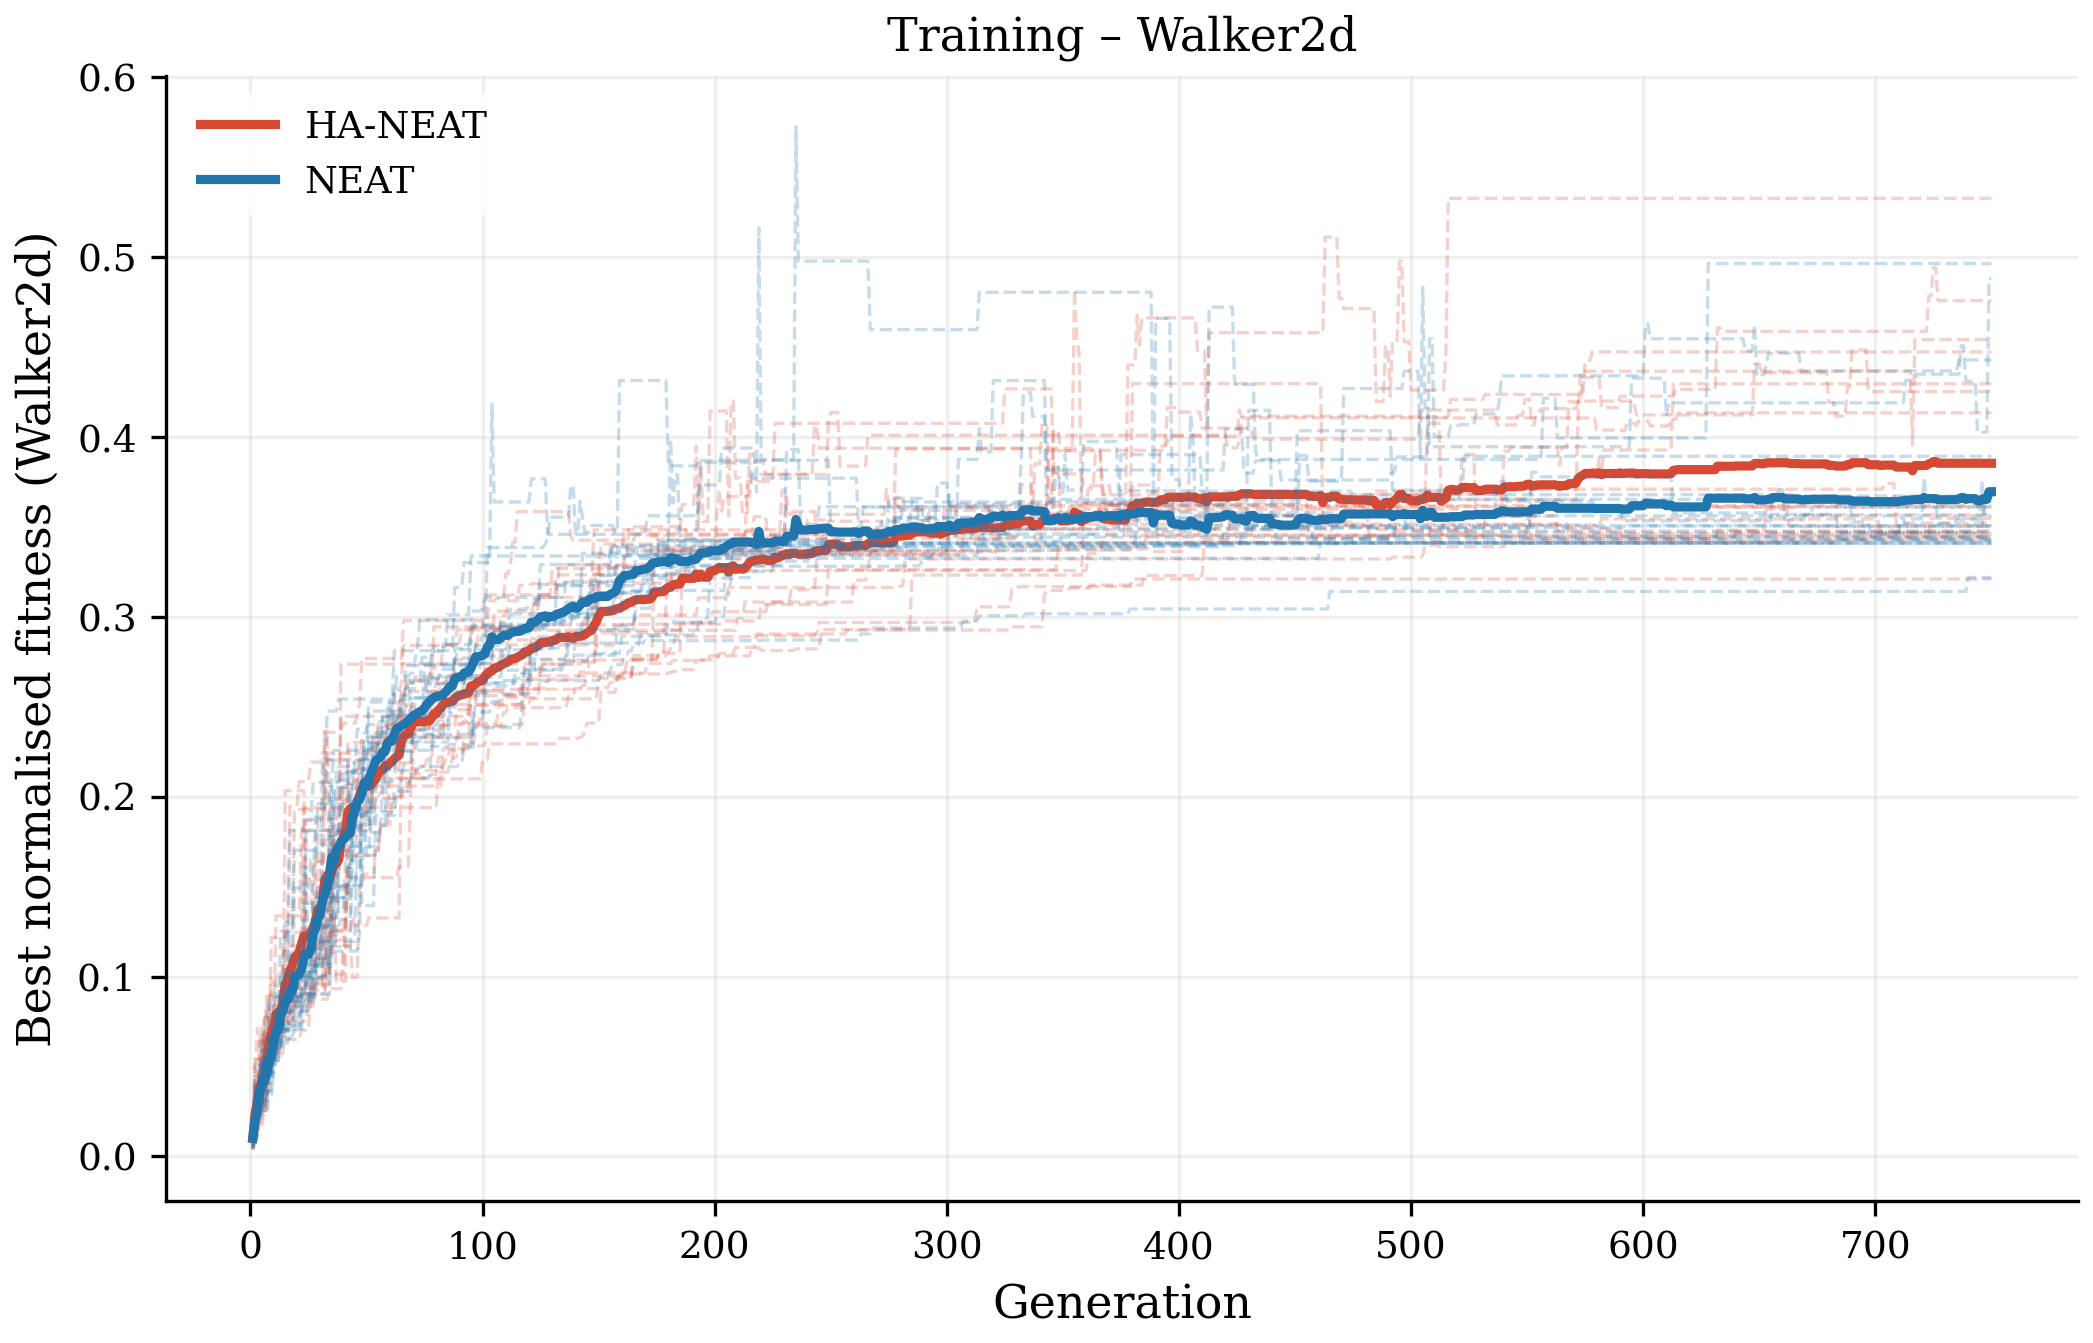

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/training_aggregated.pdf


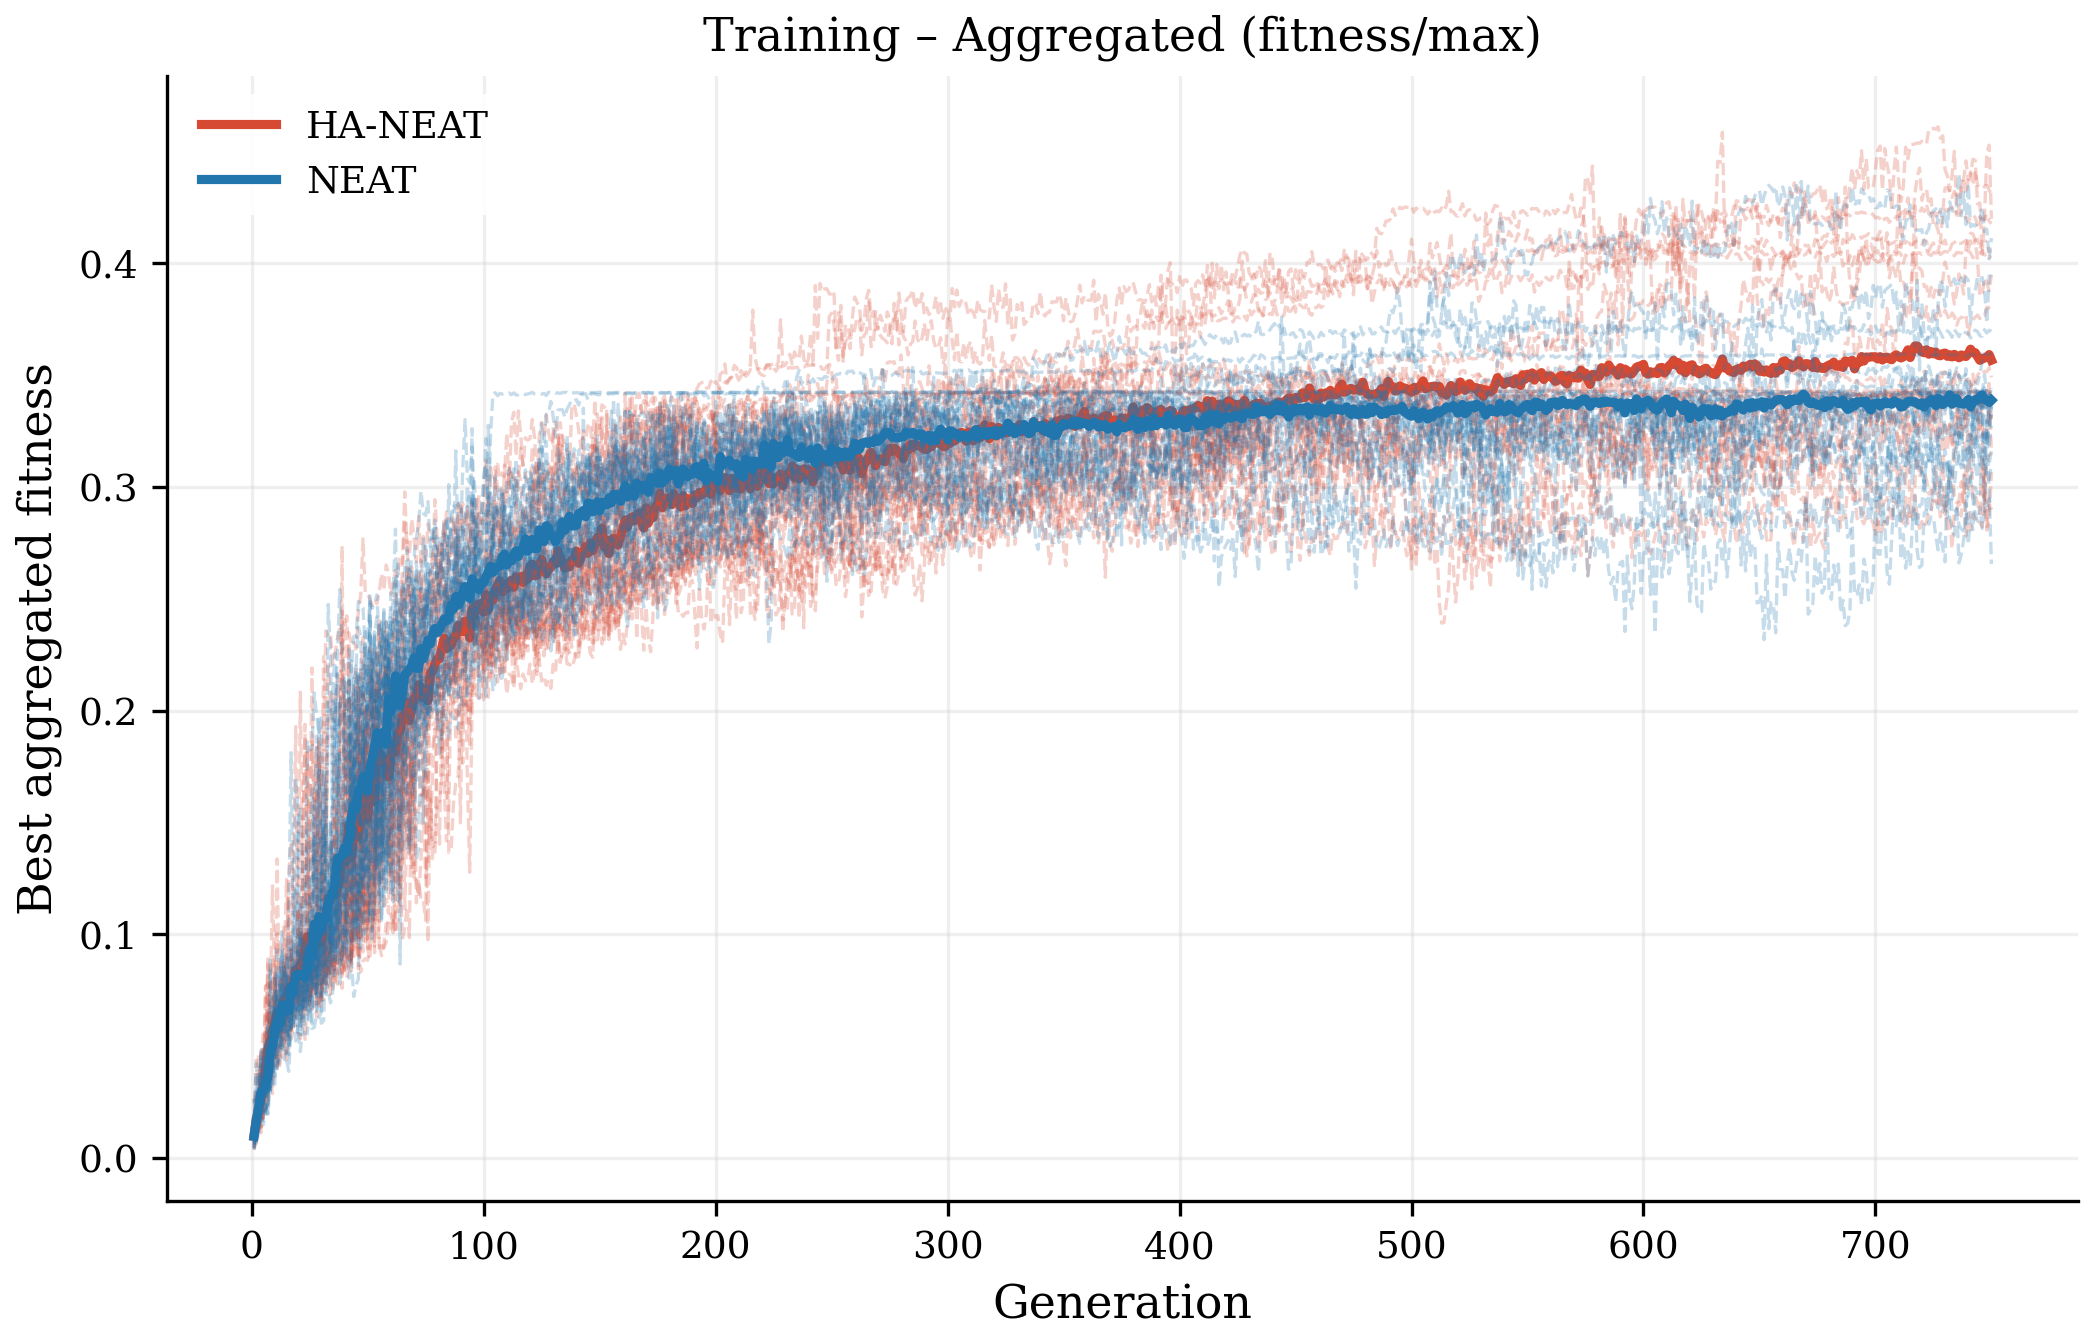

In [4]:
def plot_metric_curves(data, metric_key, ylabel, title, ax=None, save_path=None):
    """Plot per-seed dashed traces + bold mean per algorithm for a given metric."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    else:
        fig = ax.get_figure()

    groups = _group_by_algorithm(data)
    for algo in sorted(groups):
        color = ALGO_COLORS.get(algo, "#555555")
        label = ALGO_DISPLAY.get(algo, algo)
        all_steps, all_vals = [], []
        for run_name in groups[algo]:
            if metric_key not in data[run_name]:
                continue
            steps, vals = _extract_series(data[run_name][metric_key])
            if len(steps) == 0:
                continue
            all_steps.append(steps)
            all_vals.append(vals)
            ax.plot(steps, vals, color=color, alpha=0.25, linewidth=0.8, linestyle="--")
        if all_steps:
            ms, mv = _compute_mean_curve(all_steps, all_vals)
            ax.plot(ms, mv, color=color, linewidth=2.2, label=label)

    ax.set_xlabel("Generation")
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=6)
    ax.legend(framealpha=0.9, edgecolor="none")
    fig.tight_layout(pad=0.4)

    if save_path:
        fig.savefig(save_path)
        print(f"  Saved: {save_path}")
    if own_fig:
        plt.show()
        plt.close(fig)


# Per-task normalised fitness
for task in TASKS:
    plot_metric_curves(
        mlflow_data,
        f"best_fitness_normalized/{task}",
        ylabel=f"Best normalised fitness ({task.capitalize()})",
        title=f"Training – {task.capitalize()}",
        save_path=FIGURES_DIR / f"training_{task}.pdf",
    )

# Aggregated fitness/max
plot_metric_curves(
    mlflow_data,
    "fitness/max",
    ylabel="Best aggregated fitness",
    title="Training – Aggregated (fitness/max)",
    save_path=FIGURES_DIR / "training_aggregated.pdf",
)

## 4. Genome complexity over generations

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/genome_complexity.pdf


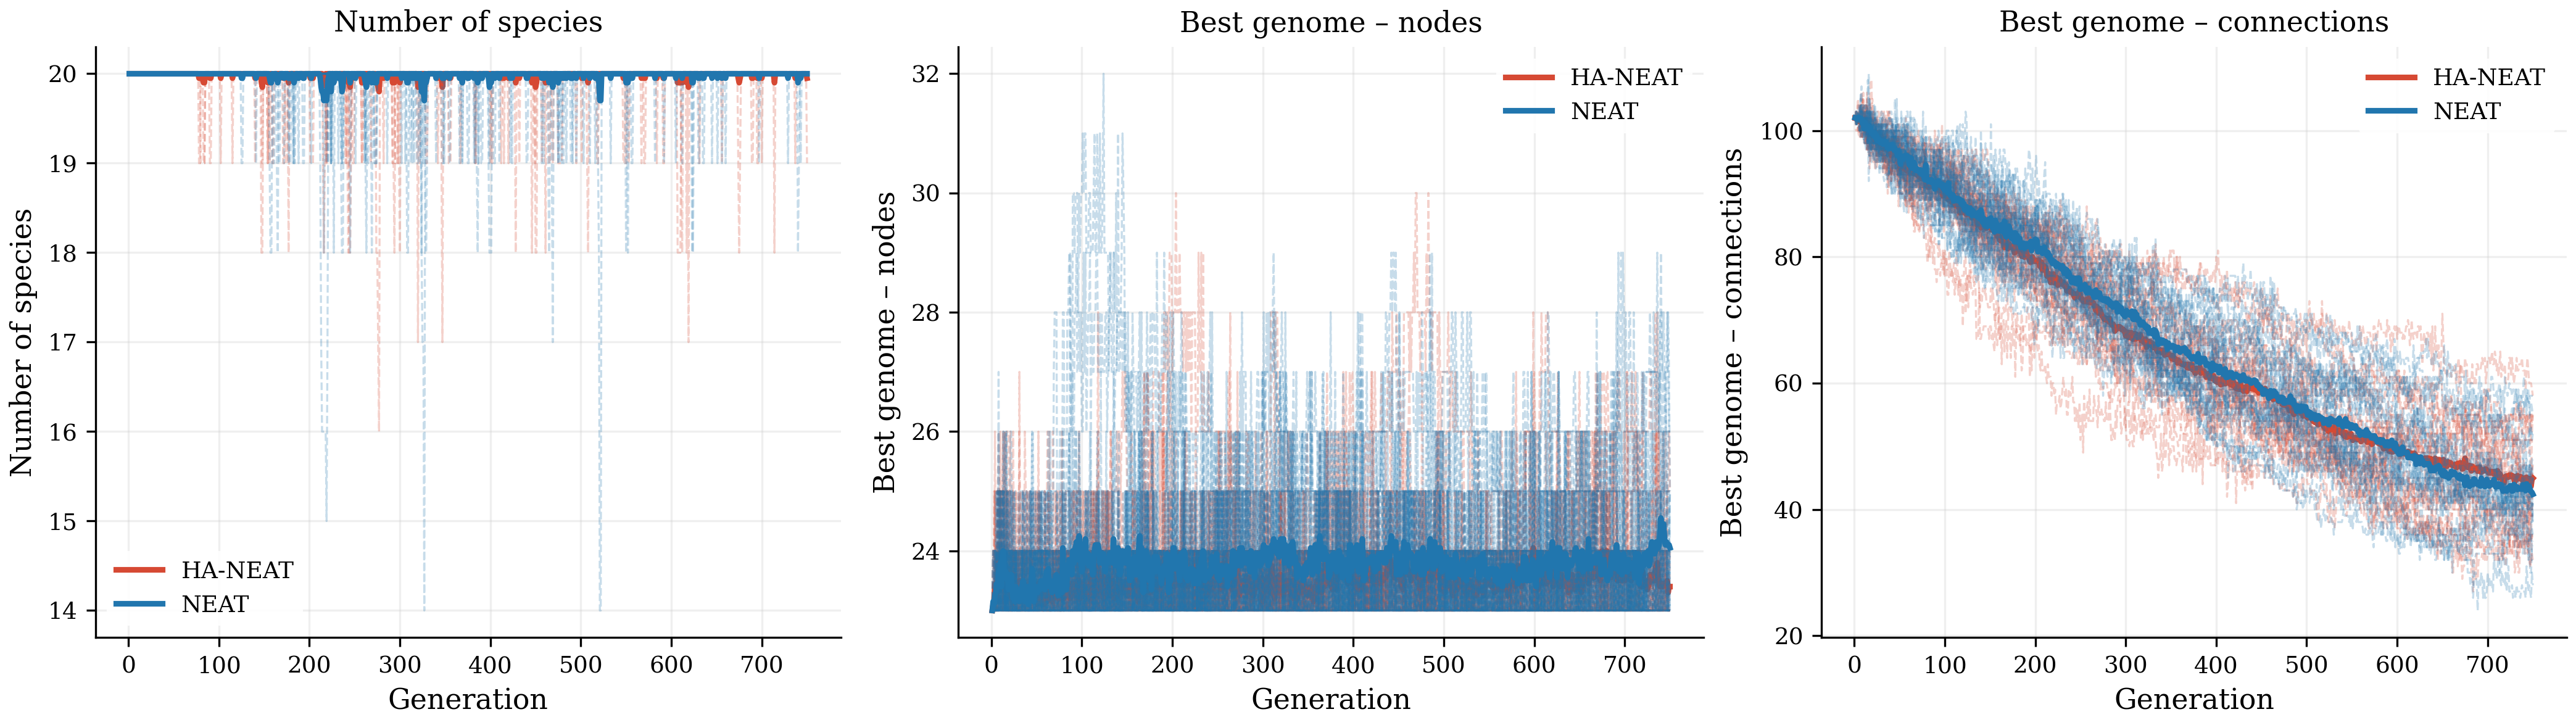

In [5]:
COMPLEXITY_METRICS = {
    "neat/n_species"          : "Number of species",
    "neat/best_genome_n_nodes": "Best genome – nodes",
    "neat/best_genome_n_conns": "Best genome – connections",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (metric_key, ylabel) in zip(axes, COMPLEXITY_METRICS.items()):
    plot_metric_curves(
        mlflow_data, metric_key,
        ylabel=ylabel,
        title=ylabel,
        ax=ax,
    )

fig.tight_layout(pad=0.6)
fig.savefig(FIGURES_DIR / "genome_complexity.pdf")
print(f"  Saved: {FIGURES_DIR / 'genome_complexity.pdf'}")
plt.show()
plt.close(fig)

In [6]:
# Final-generation summary table
summary_rows = []
for algo, run_names in sorted(_group_by_algorithm(mlflow_data).items()):
    label = ALGO_DISPLAY.get(algo, algo)
    row = {"Algorithm": label}
    for metric_key, col_name in COMPLEXITY_METRICS.items():
        final_vals = []
        for rn in run_names:
            if metric_key not in mlflow_data[rn]:
                continue
            steps, vals = _extract_series(mlflow_data[rn][metric_key])
            if len(vals):
                final_vals.append(vals[-1])
        if final_vals:
            row[col_name] = f"{np.mean(final_vals):.1f} ± {np.std(final_vals, ddof=1):.1f}"
        else:
            row[col_name] = "n/a"
    summary_rows.append(row)

df_complexity = pd.DataFrame(summary_rows).set_index("Algorithm")
print("Final-generation genome complexity (mean ± std across seeds):")
display(df_complexity)

Final-generation genome complexity (mean ± std across seeds):


,Number of species,Best genome – nodes,Best genome – connections
Algorithm,,,
HA-NEAT,19.9 ± 0.2,23.4 ± 0.7,45.0 ± 7.7
NEAT,20.0 ± 0.0,24.1 ± 1.1,42.4 ± 7.7


## 5. Activation function usage (HA-NEAT only)

Node array layout: `[node_id, bias, type_flag, activation_index]`  
Activation mapping (from config): `[tanh=0, sigmoid=1, relu=2, sin=3, identity=4]`  
Valid nodes: rows where `node_id` is not NaN.

In [7]:
# Verify activation column with one genome
sample_entry = groups["ha_neat"][0]
sample_data  = np.load(sample_entry.path)
sample_nodes = sample_data["nodes"]
valid        = sample_nodes[~np.isnan(sample_nodes[:, 0])]
print(f"Sample: {sample_entry.fname}")
print(f"Columns: [node_id, bias, type_flag, activation_idx]")
print("First 8 valid nodes:")
print(valid[:8])
print(f"Unique activation indices found: {sorted(set(valid[:, 3].astype(int)))}")
print(f"ACTIVATION_OPTIONS mapping: {list(enumerate(ACTIVATION_OPTIONS))}")

Sample: ha_neat_normalized_min_pop1024_gen750_disjoint1.0_compat0.3_seed1227.npz
Columns: [node_id, bias, type_flag, activation_idx]
First 8 valid nodes:
[[ 0.         -1.3725022   0.          1.        ]
 [ 1.          0.5215223   0.          1.        ]
 [ 2.         -0.07431313  0.          2.        ]
 [ 3.          1.3629848   0.          3.        ]
 [ 4.         -0.07733011  0.          1.        ]
 [ 5.          0.55366826  0.          3.        ]
 [ 6.          0.30836433  0.          4.        ]
 [ 7.         -0.7301338   0.          1.        ]]
Unique activation indices found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
ACTIVATION_OPTIONS mapping: [(0, 'tanh'), (1, 'sigmoid'), (2, 'relu'), (3, 'sin'), (4, 'identity')]


In [8]:
# Count activations per HA-NEAT genome
ha_entries = groups["ha_neat"]
activation_counts_per_seed = []  # list of np.array(len=5) with counts per genome

for entry in ha_entries:
    nodes = np.load(entry.path)["nodes"]
    valid = nodes[~np.isnan(nodes[:, 0])]
    act_indices = valid[:, 3].astype(int)
    counts = np.bincount(act_indices, minlength=len(ACTIVATION_OPTIONS))
    activation_counts_per_seed.append(counts)

counts_arr = np.array(activation_counts_per_seed)  # (n_seeds, 5)
mean_counts = counts_arr.mean(axis=0)
std_counts  = counts_arr.std(axis=0, ddof=1)

print("Mean node count per activation (across 20 HA-NEAT seeds):")
for name, m, s in zip(ACTIVATION_OPTIONS, mean_counts, std_counts):
    print(f"  {name:10s}  {m:.2f} ± {s:.2f}")

# Share of non-tanh activations per seed
total_counts = counts_arr.sum(axis=1)
nontanh_share = (total_counts - counts_arr[:, 0]) / total_counts
print(f"\nNon-tanh share: {nontanh_share.mean():.3f} ± {nontanh_share.std(ddof=1):.3f}")

Mean node count per activation (across 20 HA-NEAT seeds):
  tanh        4.30 ± 1.45
  sigmoid     4.65 ± 1.27
  relu        4.30 ± 1.78
  sin         5.10 ± 1.71
  identity    5.60 ± 1.88

Non-tanh share: 0.821 ± 0.060


  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/activation_usage.pdf


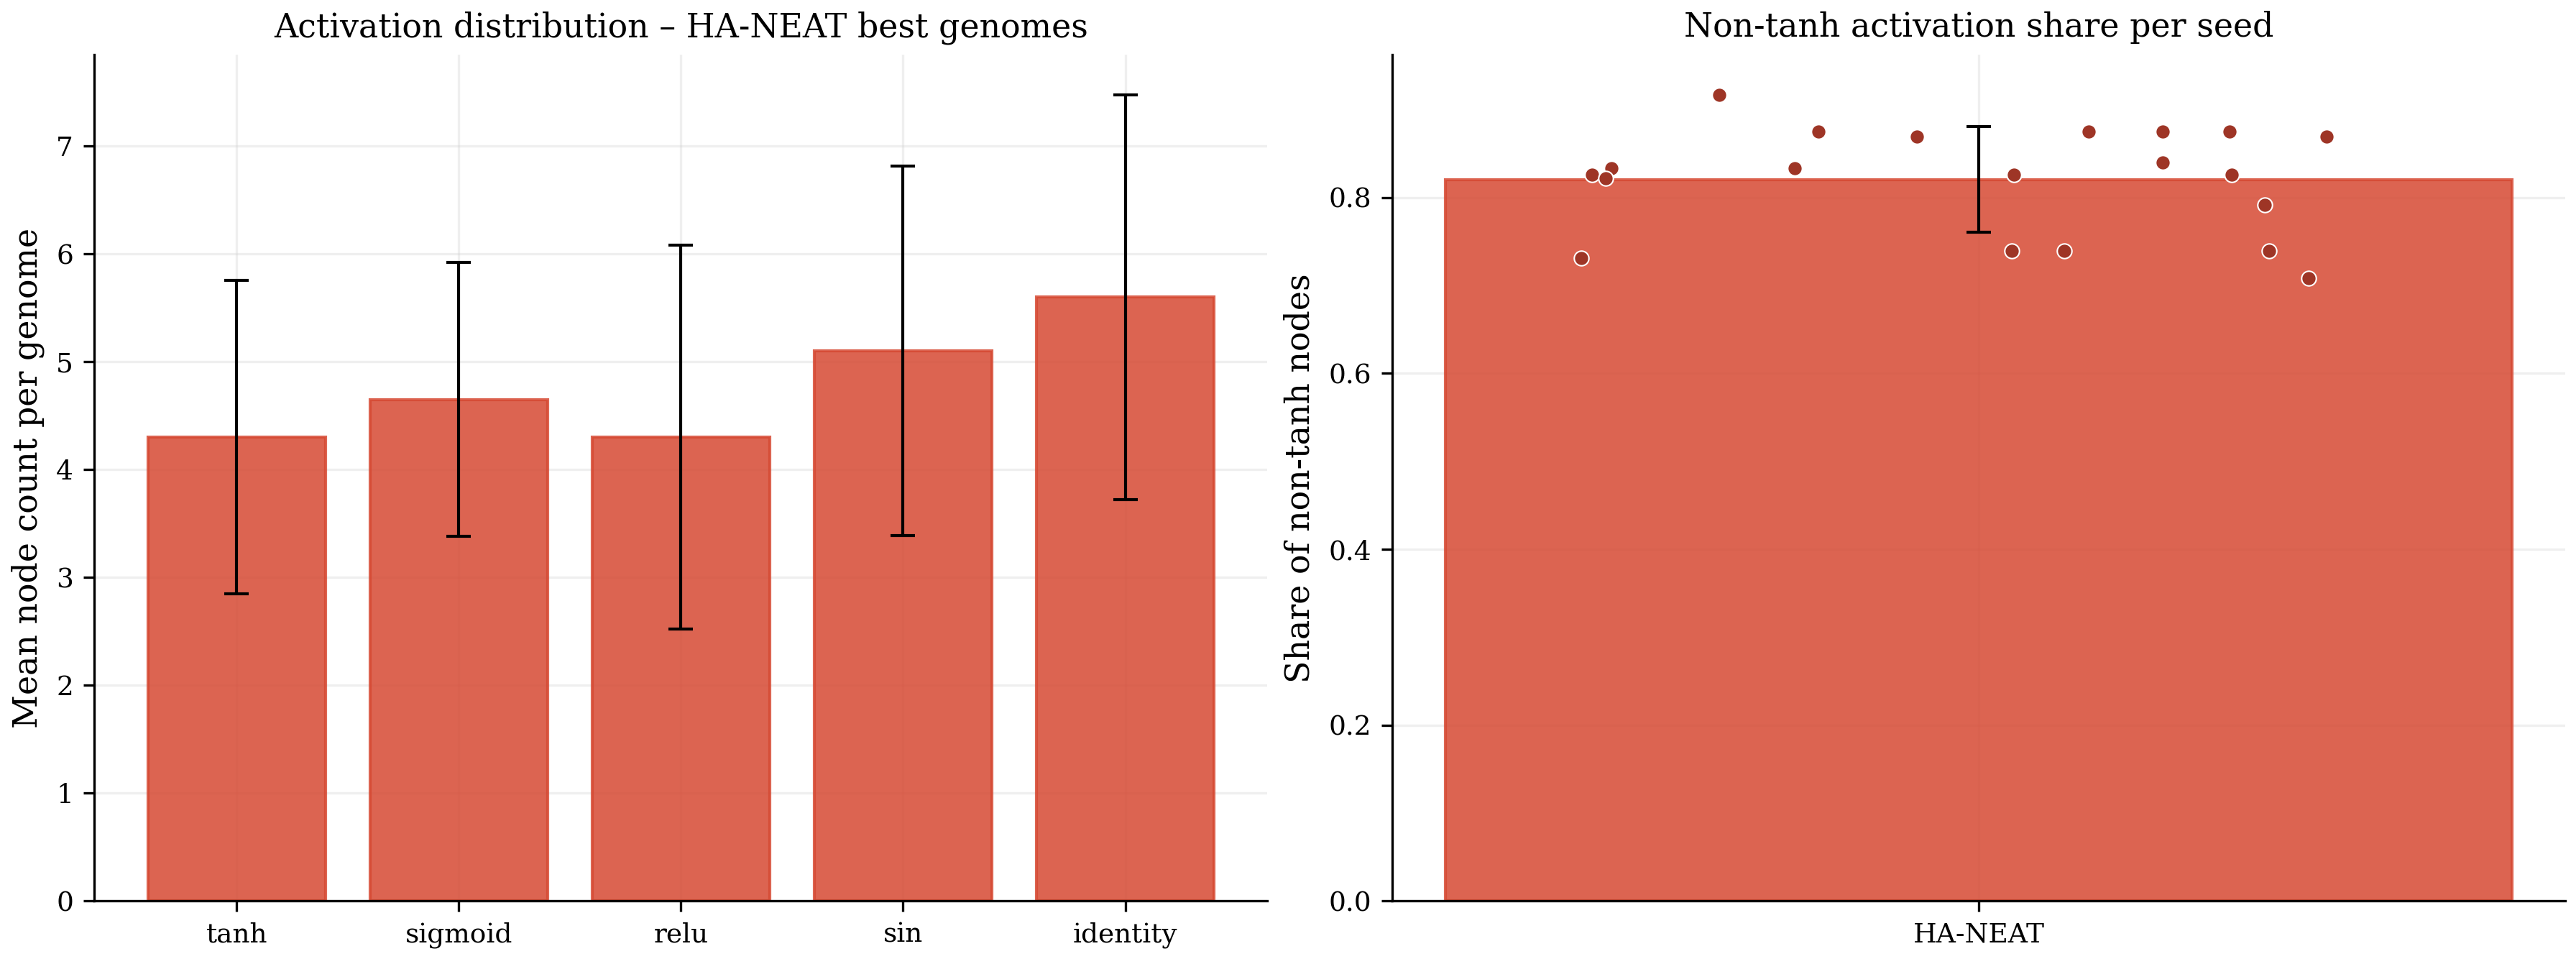

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar 1: mean count per activation
x = np.arange(len(ACTIVATION_OPTIONS))
ha_color = ALGO_COLORS["ha_neat"]
ax1.bar(x, mean_counts, yerr=std_counts, capsize=4,
        color=ha_color, alpha=0.85, edgecolor=ha_color,
        error_kw={"linewidth": 1.0, "capthick": 1.0})
ax1.set_xticks(x)
ax1.set_xticklabels(ACTIVATION_OPTIONS)
ax1.set_ylabel("Mean node count per genome")
ax1.set_title("Activation distribution – HA-NEAT best genomes")
ax1.yaxis.grid(True, alpha=0.3, color="#cccccc")
ax1.set_axisbelow(True)

# Bar 2: per-seed non-tanh share with jitter
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.15, 0.15, len(nontanh_share))
ax2.bar([0], [nontanh_share.mean()], yerr=[nontanh_share.std(ddof=1)],
        capsize=4, color=ha_color, alpha=0.85, edgecolor=ha_color,
        error_kw={"linewidth": 1.0, "capthick": 1.0}, width=0.4)
ax2.scatter(np.zeros(len(nontanh_share)) + jitter, nontanh_share,
            color=ALGO_DOT_COLORS["ha_neat"], s=24, zorder=5,
            edgecolors="white", linewidths=0.5)
ax2.set_xticks([0])
ax2.set_xticklabels(["HA-NEAT"])
ax2.set_ylabel("Share of non-tanh nodes")
ax2.set_title("Non-tanh activation share per seed")
ax2.yaxis.grid(True, alpha=0.3, color="#cccccc")
ax2.set_axisbelow(True)

fig.tight_layout(pad=0.5)
fig.savefig(FIGURES_DIR / "activation_usage.pdf")
print(f"  Saved: {FIGURES_DIR / 'activation_usage.pdf'}")
plt.show()
plt.close(fig)

## 6. Re-evaluation

Results were produced on the server (`eval/evaluate_genomes.py`, n_eval=20, MJX backend) and
saved to `analysis/outputs/multi_task_neat_vs_haneat_reduced_20260424_121849/reeval/combined.json`.
The cell below loads that file directly — no re-computation needed.

In [10]:
# Load the server-generated re-evaluation results
if not REEVAL_JSON.exists():
    raise FileNotFoundError(
        f"Re-evaluation JSON not found: {REEVAL_JSON}\n"
        "Run eval/evaluate_genomes.py on the server first."
    )

print(f"Loading re-evaluation from:\n  {REEVAL_JSON}")
with open(REEVAL_JSON) as f:
    combined = json.load(f)

meta      = combined["metadata"]
runs_ok   = [r for r in combined["runs"] if "error" not in r]
neat_runs = [r for r in runs_ok if r.get("algorithm") == "neat"]
ha_runs   = [r for r in runs_ok if r.get("algorithm") == "ha_neat"]

print(f"\nMetadata:")
print(f"  experiment : {meta.get('experiment')}")
print(f"  n_eval     : {meta.get('n_eval')} episodes per genome per task")
print(f"  backend    : {meta.get('backend')}")
print(f"  n_genomes  : {meta.get('n_genomes')}")
print(f"  timestamp  : {meta.get('timestamp')}")
print(f"\nSuccessful re-evaluations: NEAT={len(neat_runs)}, HA-NEAT={len(ha_runs)}")

# Pretty summary table
summary = combined.get("summary", {})
rows = []
for algo, label in [("neat", "NEAT"), ("ha_neat", "HA-NEAT")]:
    if algo not in summary:
        continue
    s = summary[algo]
    for task in TASKS:
        if task not in s:
            continue
        t = s[task]
        rows.append({
            "Algorithm"    : label,
            "Task"         : task.capitalize(),
            "Mean reward"  : f"{t['mean_across_seeds']:.1f} ± {t['std_across_seeds']:.1f}",
            "Mean norm."   : f"{t['mean_normalized']:.4f} ± {t['std_normalized']:.4f}",
            "N seeds"      : t["n_seeds"],
        })

df_summary = pd.DataFrame(rows).set_index(["Algorithm", "Task"])
print()
display(df_summary)

Loading re-evaluation from:
  /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/multi_task_neat_vs_haneat_reduced_20260424_121849/reeval/combined.json

Metadata:
  experiment : combined_final
  n_eval     : 20 episodes per genome per task
  backend    : mjx
  n_genomes  : 40
  timestamp  : 20260424_201753

Successful re-evaluations: NEAT=20, HA-NEAT=20



Mean reward       Mean norm.  N seeds
Algorithm Task                                              
NEAT      Hopper    1012.7 ± 132.8  0.3376 ± 0.0443       20
          Walker2d  1204.5 ± 387.0  0.2409 ± 0.0774       20
HA-NEAT   Hopper    1096.0 ± 106.4  0.3653 ± 0.0355       20
          Walker2d  1326.8 ± 583.0  0.2654 ± 0.1166       20

## 7. Re-evaluation plots

In [11]:
# 7a. Grouped bar charts (normalised) — reuse existing function
combined_labeled = dict(combined)
combined_labeled["metadata"] = dict(combined["metadata"])
combined_labeled["metadata"]["experiment"] = EXPERIMENT

plot_evaluation(combined_labeled, TASKS, str(FIGURES_DIR), "pdf", normalized=True)
plot_evaluation(combined_labeled, TASKS, str(FIGURES_DIR), "pdf", normalized=False)

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/multi_task_neat_vs_haneat_reduced_evaluation_normalized.pdf
  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/multi_task_neat_vs_haneat_reduced_evaluation.pdf


  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/distribution_violin.pdf


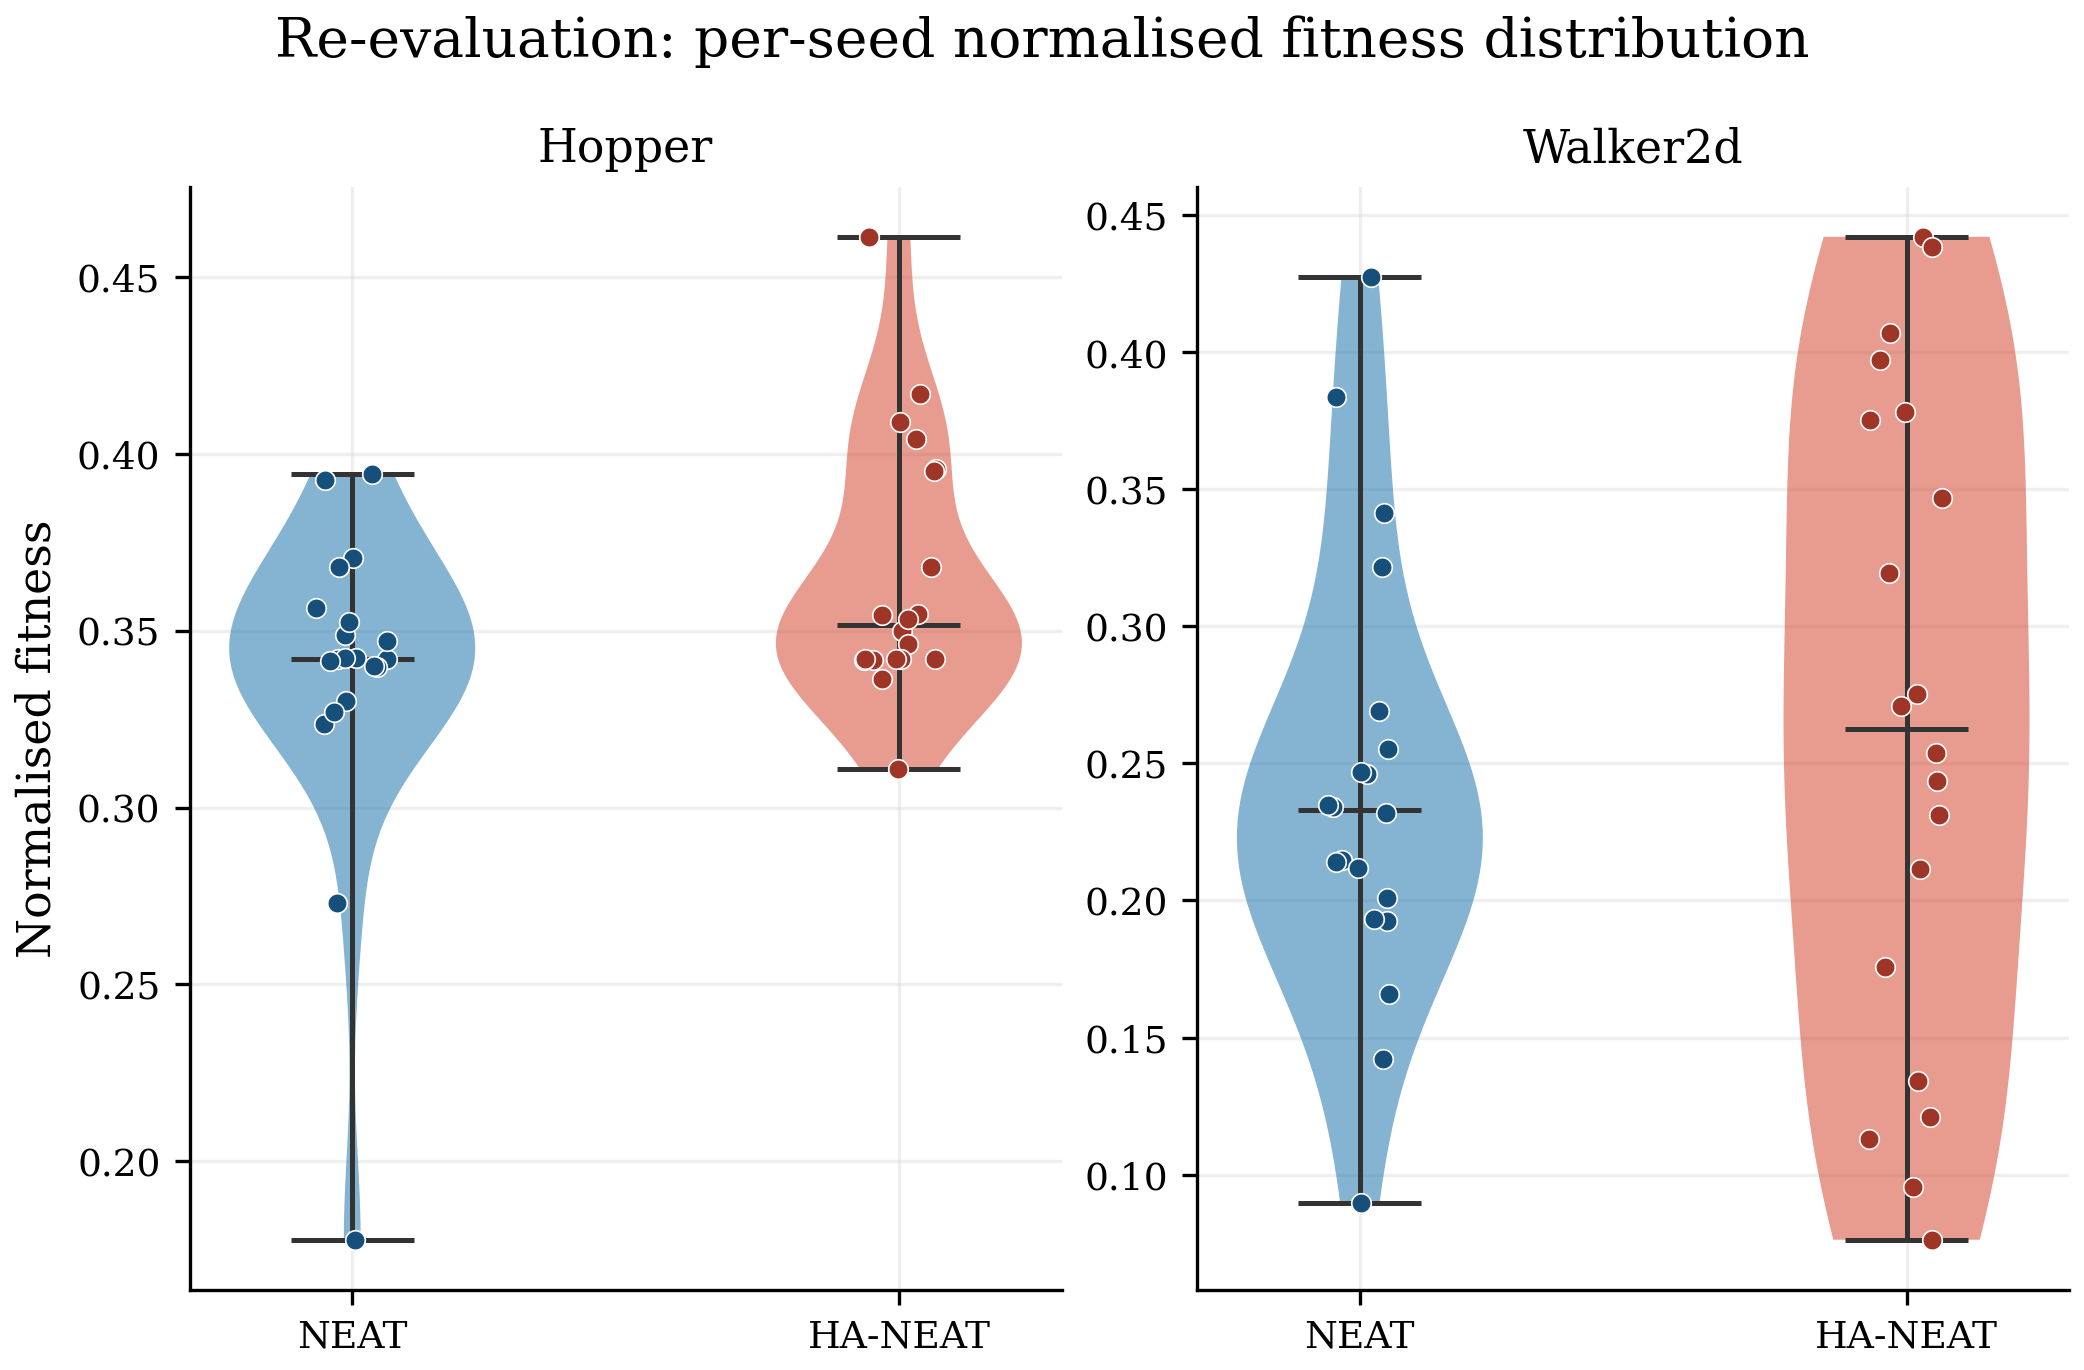

In [12]:
# 7b. Distribution plots: violin + strip per task, per algorithm
def _seed_task_means(run_list, task):
    ref = REFERENCE_REWARDS.get(task, 1.0)
    return np.array([r["tasks"][task]["mean"] / ref
                     for r in run_list if task in r.get("tasks", {})])

fig, axes = plt.subplots(1, len(TASKS), figsize=(7, 4.5))
if len(TASKS) == 1:
    axes = [axes]

rng = np.random.default_rng(1)
for ax, task in zip(axes, TASKS):
    neat_vals = _seed_task_means(neat_runs, task)
    ha_vals   = _seed_task_means(ha_runs,   task)

    vp = ax.violinplot([neat_vals, ha_vals], positions=[0, 1],
                       showmedians=True, widths=0.45)
    colors = [ALGO_COLORS["neat"], ALGO_COLORS["ha_neat"]]
    for body, c in zip(vp["bodies"], colors):
        body.set_facecolor(c)
        body.set_alpha(0.55)
    for part in ["cbars", "cmins", "cmaxes", "cmedians"]:
        vp[part].set_color("#333333")
        vp[part].set_linewidth(1.2)

    for pos, vals, dc in zip([0, 1],
                              [neat_vals, ha_vals],
                              [ALGO_DOT_COLORS["neat"], ALGO_DOT_COLORS["ha_neat"]]):
        jitter = rng.uniform(-0.07, 0.07, len(vals))
        ax.scatter(np.full(len(vals), pos) + jitter, vals,
                   color=dc, s=22, zorder=5, edgecolors="white", linewidths=0.4)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["NEAT", "HA-NEAT"])
    ax.set_ylabel("Normalised fitness" if task == TASKS[0] else "")
    ax.set_title(task.capitalize())
    ax.yaxis.grid(True, alpha=0.3, color="#cccccc")
    ax.set_axisbelow(True)

fig.suptitle("Re-evaluation: per-seed normalised fitness distribution", y=1.01)
fig.tight_layout(pad=0.5)
fig.savefig(FIGURES_DIR / "distribution_violin.pdf")
print(f"  Saved: {FIGURES_DIR / 'distribution_violin.pdf'}")
plt.show()
plt.close(fig)

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/reduced/figures/scatter_train_vs_reeval.pdf


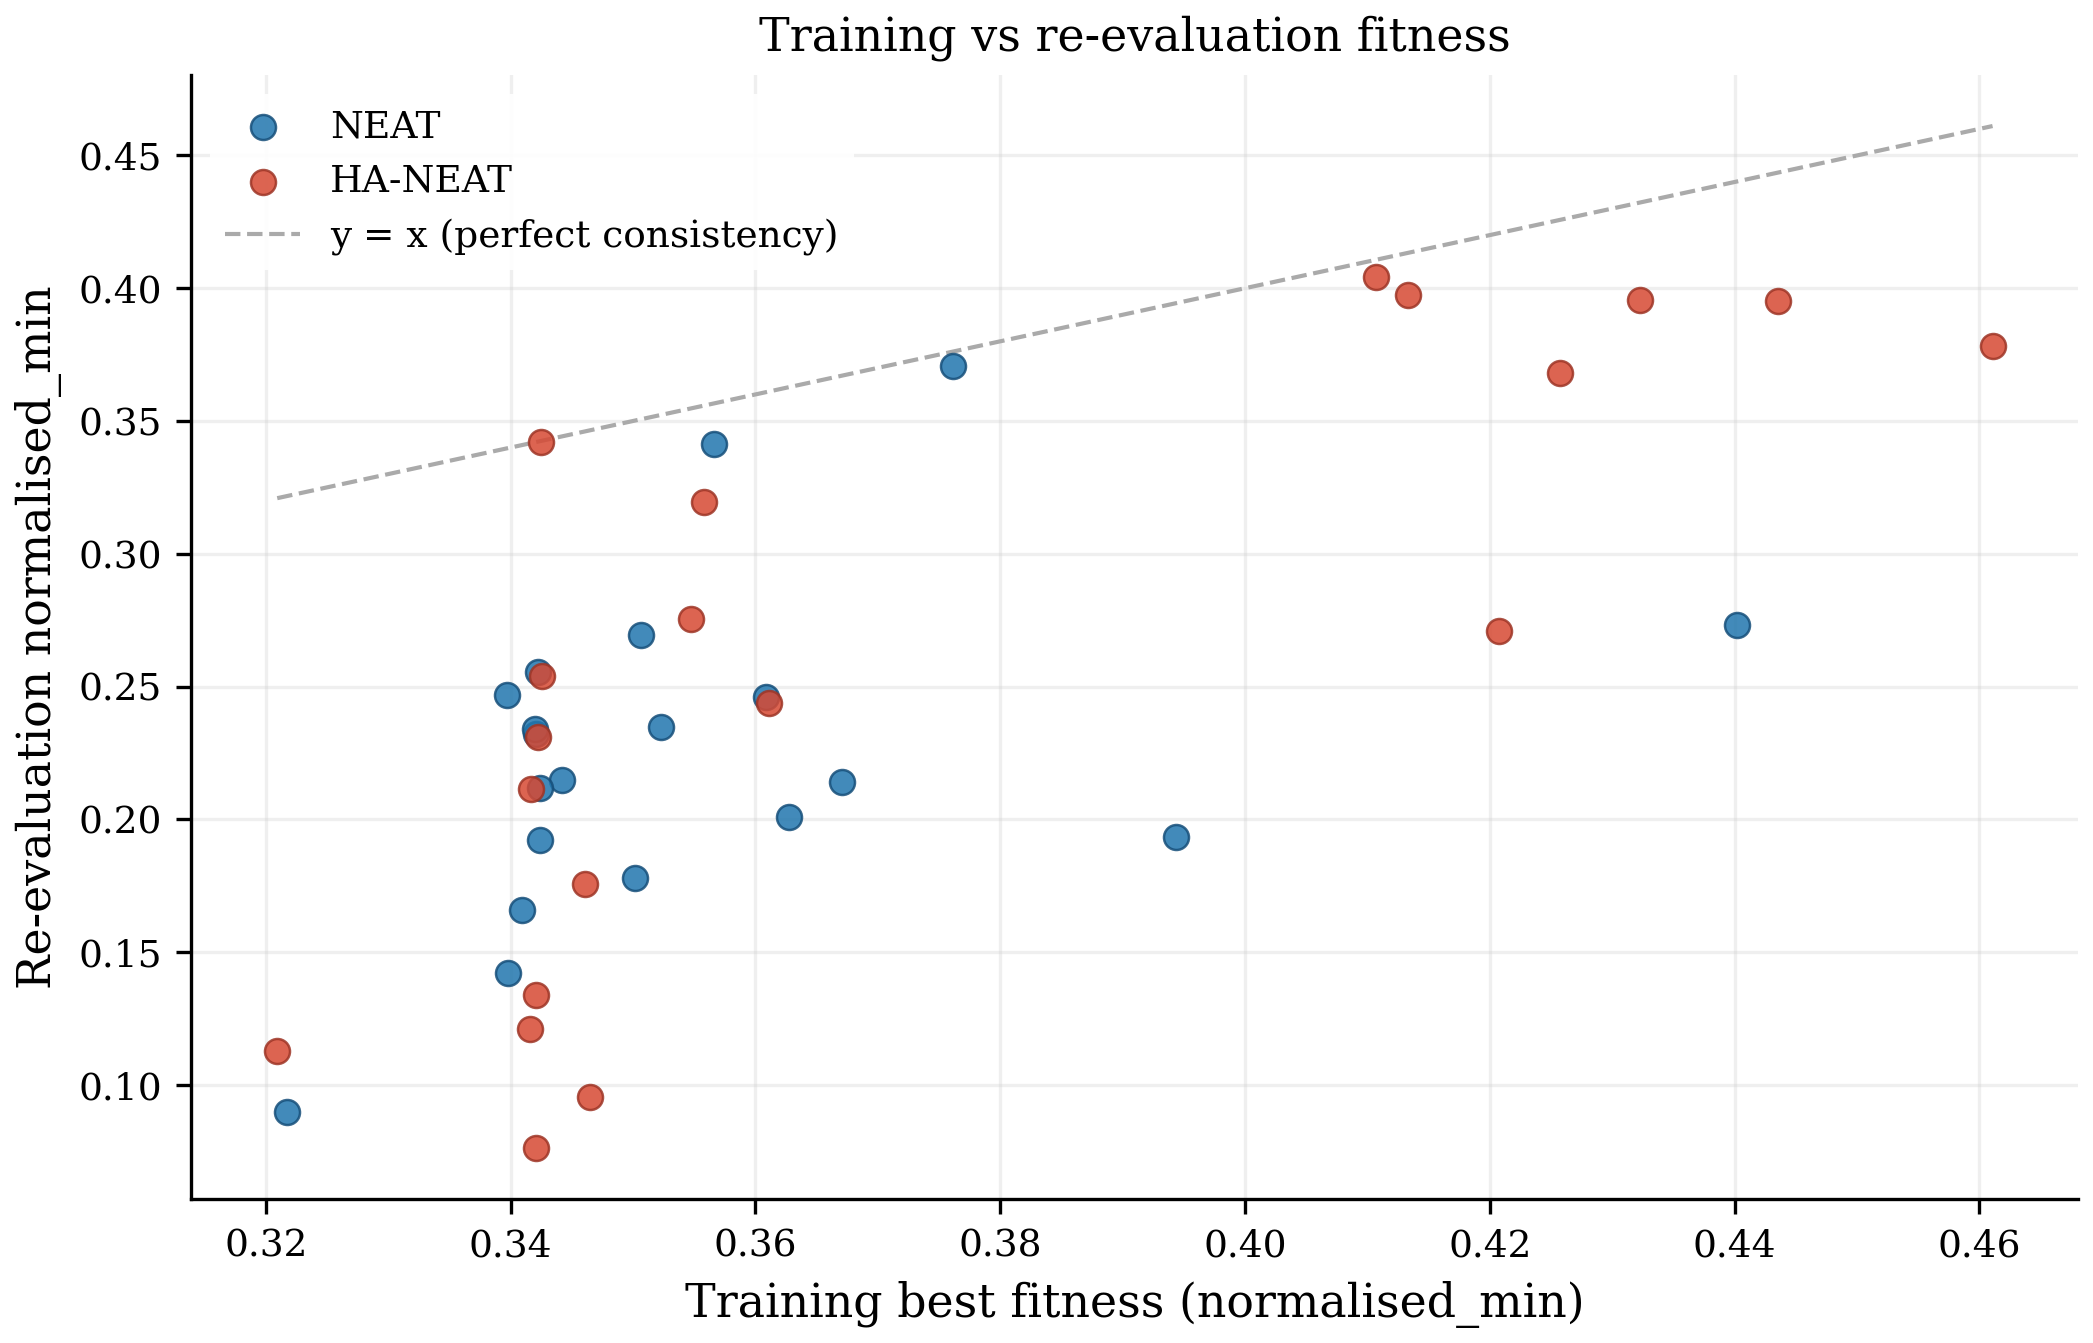

In [13]:
# 7c. Per-seed scatter: training best fitness vs re-eval normalized_min
# training_fitness is stored directly in the JSON; no need to reload .npz files

def _reeval_norm_min(run):
    norms = run.get("normalized", {})
    if "hopper" in norms and "walker2d" in norms:
        return min(norms["hopper"], norms["walker2d"])
    return None

fig, ax = plt.subplots(figsize=(7, 4.5))

for algo, run_list in [("neat", neat_runs), ("ha_neat", ha_runs)]:
    if algo not in ALGO_COLORS:
        continue
    xs, ys = [], []
    for r in run_list:
        tf = r.get("training_fitness")
        nm = _reeval_norm_min(r)
        if tf is None or nm is None:
            continue
        xs.append(tf)
        ys.append(nm)
    ax.scatter(xs, ys,
               color=ALGO_COLORS[algo], label=ALGO_DISPLAY.get(algo, algo),
               s=36, edgecolors=ALGO_DOT_COLORS[algo], linewidths=0.6,
               zorder=4, alpha=0.85)

# y = x reference line
all_tf = [r["training_fitness"] for r in runs_ok if "training_fitness" in r]
if all_tf:
    lo, hi = min(all_tf), max(all_tf)
    ax.plot([lo, hi], [lo, hi], "--", color="#aaaaaa", linewidth=1.0,
            label="y = x (perfect consistency)", zorder=1)

ax.set_xlabel("Training best fitness (normalised_min)")
ax.set_ylabel("Re-evaluation normalised_min")
ax.set_title("Training vs re-evaluation fitness")
ax.legend(framealpha=0.9, edgecolor="none")
ax.yaxis.grid(True, alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)
fig.tight_layout(pad=0.4)
fig.savefig(FIGURES_DIR / "scatter_train_vs_reeval.pdf")
print(f"  Saved: {FIGURES_DIR / 'scatter_train_vs_reeval.pdf'}")
plt.show()
plt.close(fig)

## 8. Statistical tests + bootstrap CIs

In [14]:
test_results = compute_tests(neat_runs, ha_runs, label_a="neat", label_b="ha_neat")
print(format_txt_report(test_results, label_a="NEAT", label_b="HA-NEAT"))

Statistical Comparison: NEAT vs HA-NEAT

  Task: HOPPER

  n: NEAT=20, HA-NEAT=20
  Mean: NEAT=1012.7 ± 136.2  HA-NEAT=1096.0 ± 109.2
  Norm mean (/3000): NEAT=0.3376  HA-NEAT=0.3653

  1. Mann-Whitney U: U=135.0, p=0.0810

  2. Exact permutation test:
     observed diff=-83.2, p=0.0335 (10000 permutations)

  3. Cohen's d: -0.674 (medium)

  Task: WALKER2D

  n: NEAT=20, HA-NEAT=20
  Mean: NEAT=1204.5 ± 397.0  HA-NEAT=1326.8 ± 598.2
  Norm mean (/5000): NEAT=0.2409  HA-NEAT=0.2654

  1. Mann-Whitney U: U=172.0, p=0.4570

  2. Exact permutation test:
     observed diff=-122.3, p=0.4424 (10000 permutations)

  3. Cohen's d: -0.241 (small)

  Task: NORMALIZED_MIN

  n: NEAT=20, HA-NEAT=20
  Mean: NEAT=0.2 ± 0.1  HA-NEAT=0.3 ± 0.1
  Norm mean (/1.0): NEAT=0.2253  HA-NEAT=0.2601

  1. Mann-Whitney U: U=157.0, p=0.2503

  2. Exact permutation test:
     observed diff=-0.0, p=0.2319 (10000 permutations)

  3. Cohen's d: -0.381 (small)



In [15]:
# Bootstrap 95% CIs (10 000 resamples)
def bootstrap_ci(values, stat=np.mean, n=10_000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    arr = np.asarray(values)
    boots = [stat(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n)]
    lo = np.percentile(boots, 100 * alpha / 2)
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return float(lo), float(hi)

def format_ci(val, lo, hi, ref=1.0):
    return f"{val/ref:.4f} [{lo/ref:.4f}, {hi/ref:.4f}]"

# Build combined table: test_results + bootstrap CIs
table_rows = []

from analysis.stats import _seed_means

task_order = TASKS + ["normalized_min"]
for task in task_order:
    ref = REFERENCE_REWARDS.get(task, 1.0)
    r   = test_results[task]

    if task == "normalized_min":
        ma = np.array(compute_normalized_min(neat_runs))
        mb = np.array(compute_normalized_min(ha_runs))
        ref = 1.0
    else:
        ma = _seed_means(neat_runs, task)
        mb = _seed_means(ha_runs,   task)

    ci_a  = bootstrap_ci(ma)
    ci_b  = bootstrap_ci(mb)
    diffs = bootstrap_ci(mb - ma[:len(mb)])
    obs_diff = r["observed_diff"]

    table_rows.append({
        "Task"          : task,
        "NEAT mean [95%CI]"     : format_ci(r["mean_a"], *ci_a, ref=ref),
        "HA-NEAT mean [95%CI]"  : format_ci(r["mean_b"], *ci_b, ref=ref),
        "Δ mean [95%CI]"        : f"{obs_diff/ref:.4f} [{diffs[0]/ref:.4f}, {diffs[1]/ref:.4f}]",
        "Mann-Whitney p"        : f"{r['p_mannwhitney']:.4f}" if r['p_mannwhitney'] is not None else "n/a",
        "Permutation p"         : f"{r['p_permutation']:.4f}",
        "Cohen's d"             : f"{r['cohens_d']:.3f} ({r['magnitude']})",
    })

df_stats = pd.DataFrame(table_rows).set_index("Task")
display(df_stats)

,NEAT mean [95%CI],HA-NEAT mean [95%CI],Δ mean [95%CI],Mann-Whitney p,Permutation p,Cohen's d
Task,,,,,,
hopper,"0.3376 [0.3159, 0.3543]","0.3653 [0.3509, 0.3820]","-0.0277 [0.0015, 0.0624]",0.0810,0.0335,-0.674 (medium)
walker2d,"0.2409 [0.2083, 0.2763]","0.2654 [0.2131, 0.3153]","-0.0245 [-0.0367, 0.0876]",0.4570,0.4424,-0.241 (small)
normalized_min,"0.2253 [0.1990, 0.2531]","0.2601 [0.2106, 0.3067]","-0.0348 [-0.0195, 0.0919]",0.2503,0.2319,-0.381 (small)


## 9. Summary

The `multi_task_neat_vs_haneat_reduced` experiment provides a high-seed-count (n=20/arm) comparison between standard NEAT and HA-NEAT at moderate scale (pop 1024, 750 generations). Because the experiment ran a single compatibility threshold (compat=0.3) without ablation variants, the design cleanly isolates the effect of heterogeneous activation functions.

The statistical tests above follow the same methodology as the final experiment (Mann-Whitney U + exact permutation + Cohen's d), and the bootstrap confidence intervals for the mean difference give a direct read on effect magnitude. This positions the reduced experiment as a replication check and seed-count extension of the main results reported in §5 of the thesis.

**Figures written to:**

In [16]:
for f in sorted(FIGURES_DIR.glob("*")):
    print(f"  {f.relative_to(PROJECT_ROOT)}")

  analysis/outputs/reduced/figures/activation_usage.pdf
  analysis/outputs/reduced/figures/distribution_violin.pdf
  analysis/outputs/reduced/figures/genome_complexity.pdf
  analysis/outputs/reduced/figures/multi_task_neat_vs_haneat_reduced_evaluation.pdf
  analysis/outputs/reduced/figures/multi_task_neat_vs_haneat_reduced_evaluation_normalized.pdf
  analysis/outputs/reduced/figures/scatter_train_vs_reeval.pdf
  analysis/outputs/reduced/figures/training_aggregated.pdf
  analysis/outputs/reduced/figures/training_hopper.pdf
  analysis/outputs/reduced/figures/training_walker2d.pdf
